<a href="https://colab.research.google.com/github/HarleylimaDados/analise-precos-combustiveis-anp/blob/main/analise_precos_combustiveis_anp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise exploratória: preços de combustíveis no Brasil (ANP, 2023 a 2026)

## 1. Contexto
Neste projeto analiso os preços de combustíveis no Brasil com a Série Histórica de Preços de Combustíveis da ANP, a pesquisa semanal que a agência faz nos postos.

A ideia é responder perguntas práticas sobre preço, concorrência e economia, com foco em São José do Rio Preto e no noroeste paulista.

- Período: 1º semestre de 2023 ao 1º semestre de 2026
- Ferramentas: Python (Pandas, Matplotlib e Seaborn) e SQL (SQLite)
- Fonte: [ANP, dados abertos](https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/serie-historica-de-precos-de-combustiveis)

### Resumo dos resultados
- Em Rio Preto, o etanol ficou abaixo de 70% do preço da gasolina em 93% dos meses (jan/2023 a jun/2026). Nenhum estado teve índice maior.
- Escolher o posto pesa mais do que escolher a bandeira. Em Rio Preto, os postos mais baratos economizam cerca de R\$ 29 por tanque de gasolina, enquanto a bandeira explica de 13 a 17 centavos por litro.
- A gasolina subiu cerca de 32% no período. Diesel S10 e etanol subiram perto de 10% cada (média do Brasil).
- Entre os estados, o preço do etanol varia o dobro do da gasolina (37% contra 18%). SP tem o etanol mais barato do país.

Os detalhes estão em cada pergunta, e as recomendações, na seção 5.

## 2. Dados

Baixo os 7 semestres direto do portal da ANP, confiro o arquivo bruto e carrego tudo com o Pandas.

In [1]:
import io
import os
import sqlite3
import time
import zipfile

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import requests
import seaborn as sns

In [2]:
url = "https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsas/ca/ca-2026-01.zip"

resposta = requests.get(url, timeout=120)
print("Status:", resposta.status_code)
print("Tamanho (MB):", round(len(resposta.content)/ 1_000_000, 1))

arquivo_zip = zipfile.ZipFile(io.BytesIO(resposta.content))
print("Arquivos dentro do zip:", arquivo_zip.namelist())


Status: 200
Tamanho (MB): 8.5
Arquivos dentro do zip: ['Preços semestrais - AUTOMOTIVOS_2026.01.csv']


In [3]:
nome_csv = arquivo_zip.namelist()[0]

with arquivo_zip.open(nome_csv) as arquivo:
  trecho = arquivo.read(1000)

print(trecho.decode("utf-8-sig", errors="ignore"))

Regiao - Sigla;Estado - Sigla;Municipio;Revenda;CNPJ da Revenda;Nome da Rua;Numero Rua;Complemento;Bairro;Cep;Produto;Data da Coleta;Valor de Venda;Valor de Compra;Unidade de Medida;Bandeira
N;AC;CRUZEIRO DO SUL;AMAZONIA COMERCIO DE DERIVADOS DE PETROLEO LTDA; 01.492.748/0003-83;AVENIDA COPACABANA;440;;COPACABANA;69980-000;GASOLINA;02/01/2026;7,97;;R$ / litro;IPIRANGA
N;AC;CRUZEIRO DO SUL;AMAZONIA COMERCIO DE DERIVADOS DE PETROLEO LTDA; 01.492.748/0003-83;AVENIDA COPACABANA;440;;COPACABANA;69980-000;DIESEL;02/01/2026;8,15;;R$ / litro;IPIRANGA
N;AC;CRUZEIRO DO SUL;AMAZONIA COMERCIO DE DERIVADOS DE PETROLEO LTDA; 01.492.748/0003-83;AVENIDA COPACABANA;440;;COPACABANA;69980-000;DIESEL S10;02/01/2026;8,17;;R$ / litro;IPIRANGA
N;AC;RIO BRANCO;AUTO POSTO AMAPA LTDA; 00.529.581/0001-53;VIA CHICO MENDES;3570;;AREAL;69906-119;GASOLINA;02/01/2026;7,29;;R$ / litro;VIBRA
N;AC;RIO BRANCO;AUTO POSTO AMAPA LTDA; 00.529.581/0001-53;VIA CHICO MENDES;3570;;AREAL;69906-119;GASOLINA ADITIVADA;02/01


In [4]:
with arquivo_zip.open(nome_csv) as arquivo:
  df_teste = pd.read_csv(arquivo, sep=";", decimal=",", encoding="utf-8-sig")

print(df_teste.shape)
df_teste.info()

(422418, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 422418 entries, 0 to 422417
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Regiao - Sigla     422418 non-null  object 
 1   Estado - Sigla     422418 non-null  object 
 2   Municipio          422418 non-null  object 
 3   Revenda            422418 non-null  object 
 4   CNPJ da Revenda    422418 non-null  object 
 5   Nome da Rua        422418 non-null  object 
 6   Numero Rua         422412 non-null  object 
 7   Complemento        96159 non-null   object 
 8   Bairro             421690 non-null  object 
 9   Cep                422418 non-null  object 
 10  Produto            422418 non-null  object 
 11  Data da Coleta     422418 non-null  object 
 12  Valor de Venda     422418 non-null  float64
 13  Valor de Compra    0 non-null       float64
 14  Unidade de Medida  422418 non-null  object 
 15  Bandeira           422418 non-null  ob

### Primeira olhada no arquivo (1º semestre de 2026)
- 422.418 linhas e 16 colunas.
- Arquivo em UTF-8 com BOM, separador `;` e decimal com vírgula.
- `Valor de Compra` está 100% vazia: não dá para calcular margem.
- `Data da Coleta` veio como texto e será convertida na limpeza.

In [5]:
COLUNAS = [
    "Regiao - Sigla", "Estado - Sigla", "Municipio", "Revenda", "CNPJ da Revenda",
    "Produto", "Data da Coleta", "Valor de Venda", "Valor de Compra",
    "Unidade de Medida", "Bandeira",
]

def baixar_semestre(ano, semestre, tentativas=3):
    url = f"https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsas/ca/ca-{ano}-{semestre:02d}.zip"

    # O site da ANP às vezes corta o download no meio (IncompleteRead).
    # Por isso, a função tenta de novo até 3 vezes antes de desistir.
    for tentativa in range(1, tentativas + 1):
        try:
            resposta = requests.get(url, timeout=120)
            resposta.raise_for_status()
            break
        except requests.exceptions.RequestException as erro:
            print(f"{ano}.{semestre}: falha na tentativa {tentativa} ({type(erro).__name__})")
            if tentativa == tentativas:
                raise
            time.sleep(10)

    arquivo_zip = zipfile.ZipFile(io.BytesIO(resposta.content))
    nome_csv = arquivo_zip.namelist()[0]

    with arquivo_zip.open(nome_csv) as arquivo:
        df = pd.read_csv(arquivo, sep=";", decimal=",", encoding="utf-8-sig", usecols=COLUNAS)

    df["semestre"] = f"{ano}.{semestre}"
    return df

In [6]:
semestres = [(2023, 1), (2023, 2), (2024, 1), (2024, 2), (2025, 1), (2025, 2), (2026, 1)]

lista_dfs = []
for ano, semestre in semestres:
    df_semestre = baixar_semestre(ano, semestre)
    print(f"{ano}.{semestre}: {len(df_semestre):,} linhas")
    lista_dfs.append(df_semestre)

df = pd.concat(lista_dfs, ignore_index=True)
print(f"Total: {len(df):,} linhas")

2023.1: 431,576 linhas
2023.2: 472,424 linhas
2024.1: 477,154 linhas
2024.2: 421,382 linhas


/tmp/ipykernel_3566/722191504.py:27: DtypeWarning: Columns (0,1,2,3,4,10,11,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo, sep=";", decimal=",", encoding="utf-8-sig", usecols=COLUNAS)


2025.1: 429,523 linhas
2025.2: 384,208 linhas
2026.1: 422,418 linhas
Total: 3,038,685 linhas


In [7]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3038685 entries, 0 to 3038684
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Regiao - Sigla     object 
 1   Estado - Sigla     object 
 2   Municipio          object 
 3   Revenda            object 
 4   CNPJ da Revenda    object 
 5   Produto            object 
 6   Data da Coleta     object 
 7   Valor de Venda     float64
 8   Valor de Compra    float64
 9   Unidade de Medida  object 
 10  Bandeira           object 
 11  semestre           object 
dtypes: float64(2), object(10)
memory usage: 1.7 GB


### Dados carregados
- 7 semestres, 3.038.685 linhas e 12 colunas (1,7 GB na memória).
- No 1º semestre de 2025 apareceu um `DtypeWarning` (tipos misturados em algumas colunas). A causa aparece logo no começo da limpeza.

## 3. Limpeza

Cada passo tem um comentário curto no código. No fim da seção, uma tabela resume todas as decisões e quantas linhas cada uma afetou.

In [8]:
# % de valores vazios em cada coluna
(df.isna().mean() * 100).round(2)


,0
Regiao - Sigla,0.3
Estado - Sigla,0.3
Municipio,0.3
Revenda,0.3
CNPJ da Revenda,0.3
Produto,0.3
Data da Coleta,0.3
Valor de Venda,0.3
Valor de Compra,100.0
Unidade de Medida,0.3


In [9]:
# Em quais semestres aparecem as linhas sem produto
df[df["Produto"].isna()]["semestre"].value_counts()

,count
semestre,
2025.1,9114


In [10]:
# Essas linhas estão vazias de ponta a ponta
df[df["Produto"].isna()].head()

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira,semestre
2222945,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.1
2222946,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.1
2222947,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.1
2222948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.1
2222949,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.1


In [11]:
# Remove as linhas totalmente vazias e a coluna Valor de Compra (100% vazia)
linhas_antes = len(df)

colunas_dados = df.columns.drop(["Valor de Compra", "semestre"])
df = df.dropna(subset=colunas_dados, how="all")

df = df.drop(columns="Valor de Compra")

print(f"Linhas antes: {linhas_antes:,}")
print(f"Linhas removidas: {linhas_antes - len(df):,}")
print(f"Linhas depois: {len(df):,}")

Linhas antes: 3,038,685
Linhas removidas: 9,114
Linhas depois: 3,029,571


In [12]:
# Conferindo depois da remoção
(df.isna().mean() * 100).round(2)

,0
Regiao - Sigla,0.0
Estado - Sigla,0.0
Municipio,0.0
Revenda,0.0
CNPJ da Revenda,0.0
Produto,0.0
Data da Coleta,0.0
Valor de Venda,0.0
Unidade de Medida,0.0
Bandeira,0.0


In [13]:
# Nomes curtos e sem espaço, mais fáceis de usar no código e no SQL
df = df.rename(columns={
    "Regiao - Sigla": "regiao",
    "Estado - Sigla": "estado",
    "Municipio": "municipio",
    "Revenda": "revenda",
    "CNPJ da Revenda": "cnpj",
    "Produto": "produto",
    "Data da Coleta": "data_coleta",
    "Valor de Venda": "valor_venda",
    "Unidade de Medida": "unidade",
    "Bandeira": "bandeira",
})

df.columns

Index(['regiao', 'estado', 'municipio', 'revenda', 'cnpj', 'produto',
       'data_coleta', 'valor_venda', 'unidade', 'bandeira', 'semestre'],
      dtype='object')

In [14]:
# Converte a data e cria as colunas de tempo usadas nas perguntas
df["data_coleta"] = pd.to_datetime(df["data_coleta"], format="%d/%m/%Y")

df["ano"] = df["data_coleta"].dt.year
df["mes"] = df["data_coleta"].dt.month
df["ano_mes"] = df["data_coleta"].dt.to_period("M").astype(str)
df["semana"] = df["data_coleta"].dt.to_period("W").dt.start_time

print("Primeira data:", df["data_coleta"].min())
print("Última data:", df["data_coleta"].max())
df[["data_coleta", "ano", "mes", "ano_mes", "semana"]].head()

Primeira data: 2023-01-02 00:00:00
Última data: 2026-06-30 00:00:00


,data_coleta,ano,mes,ano_mes,semana
0,2023-01-03,2023,1,2023-01,2023-01-02
1,2023-01-03,2023,1,2023-01,2023-01-02
2,2023-01-03,2023,1,2023-01,2023-01-02
3,2023-01-02,2023,1,2023-01,2023-01-02
4,2023-01-02,2023,1,2023-01,2023-01-02


In [15]:
# Padronizar o CNPJ: no arquivo do 2º semestre de 2025, o CNPJ veio como número
# (sem pontuação e sem os zeros à esquerda). Nos outros, vem como texto com um espaço no começo.
print("Tipos encontrados na coluna cnpj:")
print(df["cnpj"].map(type).value_counts())

def padronizar_cnpj(valor):
    if not isinstance(valor, str):
        valor = str(int(valor))
    somente_digitos = valor.strip().replace(".", "").replace("/", "").replace("-", "")
    return somente_digitos.zfill(14)

df["cnpj"] = df["cnpj"].map(padronizar_cnpj)

print("\nQuantidade de dígitos depois da padronização:")
print(df["cnpj"].str.len().value_counts())

Tipos encontrados na coluna cnpj:
cnpj
<class 'str'>    2645363
<class 'int'>     384208
Name: count, dtype: int64

Quantidade de dígitos depois da padronização:
cnpj
14    3029571
Name: count, dtype: int64


In [16]:
# Produtos que existem na base
df["produto"].value_counts()

,count
produto,
GASOLINA,788453
ETANOL,666801
GASOLINA ADITIVADA,613318
DIESEL S10,556388
DIESEL,340500
GNV,64111


In [17]:
# Unidade de medida de cada produto
df["unidade"].value_counts()

,count
unidade,
R$ / litro,2965460
R$ / m³,55379
R$ / m3,8732


In [18]:
print("Bandeiras diferentes:", df["bandeira"].nunique())
df["bandeira"].value_counts().head(25)


Bandeiras diferentes: 58


,count
bandeira,
BRANCA,1031171
IPIRANGA,641406
VIBRA,541156
RAIZEN,447124
VIBRA ENERGIA,99128
ALE,50257
ALESAT,47102
SABBÁ,31482
ATEM' S,13467


In [19]:
# Rio Preto e Fernandópolis estão na pesquisa?
filtro = df["municipio"].str.contains("RIO PRETO|FERNAND")
df[filtro][["estado", "municipio"]].value_counts()

,,count
estado,municipio,
SP,SAO JOSE DO RIO PRETO,12507


In [20]:
# Mantém só gasolina comum, etanol e diesel S10
produtos_analise = ["GASOLINA", "ETANOL", "DIESEL S10"]

linhas_antes = len(df)
df = df[df["produto"].isin(produtos_analise)].copy()

print(f"Linhas removidas: {linhas_antes - len(df):,}")
print(f"Linhas depois: {len(df):,}")
df["unidade"].value_counts()

Linhas removidas: 1,017,929
Linhas depois: 2,011,642


,count
unidade,
R$ / litro,2011642


In [21]:
# Junta as bandeiras em 5 grupos. Vibra entra por nome exato para não pegar a PETROBRASIL
def agrupar_bandeira(bandeira):
    if bandeira == "BRANCA":
        return "Branca"
    elif bandeira in ["VIBRA", "VIBRA ENERGIA"]:
        return "Petrobras (Vibra)"
    elif "IPIRANGA" in bandeira:
        return "Ipiranga"
    elif "RAIZEN" in bandeira or "SHELL" in bandeira:
        return "Shell (Raízen)"
    else:
        return "Outras"

df["bandeira_grupo"] = df["bandeira"].map(agrupar_bandeira)
df["bandeira_grupo"].value_counts(normalize=True).mul(100).round(1)

,proportion
bandeira_grupo,
Branca,35.6
Ipiranga,20.8
Petrobras (Vibra),20.3
Shell (Raízen),14.7
Outras,8.7


In [22]:
# Conferindo quais nomes caíram em cada grupo
df.groupby("bandeira_grupo")["bandeira"].unique()

,bandeira
bandeira_grupo,
Branca,[BRANCA]
Ipiranga,[IPIRANGA]
Outras,"[ALESAT, ATLÂNTICA, SABBÁ, CIAPETRO, TAURUS, D..."
Petrobras (Vibra),"[VIBRA ENERGIA, VIBRA]"
Shell (Raízen),"[RAIZEN, RAIZEN MIME]"


In [23]:
# Um posto não deveria ter dois preços do mesmo produto no mesmo dia
chave = ["cnpj", "produto", "data_coleta"]
duplicados = df.duplicated(subset=chave).sum()
print(f"Linhas duplicadas: {duplicados:,}")

Linhas duplicadas: 12


In [24]:
df[df.duplicated(subset=chave, keep=False)].sort_values(chave).head(6)

,regiao,estado,municipio,revenda,cnpj,produto,data_coleta,valor_venda,unidade,bandeira,semestre,ano,mes,ano_mes,semana,bandeira_grupo
1328001,SE,SP,TAUBATE,AUTO POSTO MANGUEIRA II LTDA,00008226000139,GASOLINA,2024-06-10,5.48,R$ / litro,VIBRA,2024.1,2024,6,2024-06,2024-06-10,Petrobras (Vibra)
1328003,SE,SP,TAUBATE,AUTO POSTO MANGUEIRA II LTDA,00008226000139,GASOLINA,2024-06-10,5.65,R$ / litro,VIBRA,2024.1,2024,6,2024-06,2024-06-10,Petrobras (Vibra)
1338624,SE,SP,TAUBATE,AUTO POSTO MANGUEIRA II LTDA,00008226000139,GASOLINA,2024-06-12,5.48,R$ / litro,VIBRA,2024.1,2024,6,2024-06,2024-06-10,Petrobras (Vibra)
1338626,SE,SP,TAUBATE,AUTO POSTO MANGUEIRA II LTDA,00008226000139,GASOLINA,2024-06-12,5.65,R$ / litro,VIBRA,2024.1,2024,6,2024-06,2024-06-10,Petrobras (Vibra)
1328425,SE,RJ,BARRA MANSA,POSTO METANO LTDA,03328588000103,GASOLINA,2024-06-10,5.59,R$ / litro,VIBRA,2024.1,2024,6,2024-06,2024-06-10,Petrobras (Vibra)
1328427,SE,RJ,BARRA MANSA,POSTO METANO LTDA,03328588000103,GASOLINA,2024-06-10,5.59,R$ / litro,VIBRA,2024.1,2024,6,2024-06,2024-06-10,Petrobras (Vibra)


In [25]:
# Resumo dos preços por produto, procurando valores estranhos
df.groupby("produto")["valor_venda"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
produto,,,,,,,,
DIESEL S10,556388.0,6.14,0.61,4.19,5.79,6.06,6.39,9.99
ETANOL,666801.0,4.24,0.57,2.63,3.86,4.19,4.63,7.44
GASOLINA,788453.0,5.99,0.55,4.09,5.60,5.99,6.34,9.79


In [26]:
# Remove os duplicados, mantendo a primeira coleta
linhas_antes = len(df)
df = df.drop_duplicates(subset=chave, keep="first")

print(f"Duplicados removidos: {linhas_antes - len(df):,}")
print(f"Linhas depois: {len(df):,}")

Duplicados removidos: 12
Linhas depois: 2,011,630


In [27]:
# Menor e maior preço de cada produto
indices_min = df.groupby("produto")["valor_venda"].idxmin()
indices_max = df.groupby("produto")["valor_venda"].idxmax()

extremos = pd.concat([df.loc[indices_min], df.loc[indices_max]])
extremos[["produto", "estado", "municipio", "data_coleta", "valor_venda"]]

,produto,estado,municipio,data_coleta,valor_venda
557320,DIESEL S10,ES,CARIACICA,2023-08-14,4.19
970746,ETANOL,SP,SUMARE,2024-01-24,2.63
56027,GASOLINA,SP,RIBEIRAO PRETO,2023-01-23,4.09
2693962,DIESEL S10,SP,OURINHOS,2026-02-02,9.99
2385439,ETANOL,AC,RIO BRANCO,2025-10-09,7.44
3035857,GASOLINA,SP,GUARUJA,2026-06-30,9.79


In [28]:
# Compara cada preço com a mediana do mesmo produto, estado e mês.
# Abaixo de 50% ou acima de 150% da mediana, o preço é marcado como suspeito.
mediana_contexto = df.groupby(["produto", "estado", "ano_mes"])["valor_venda"].transform("median")
df["desvio_mediana"] = df["valor_venda"] / mediana_contexto

suspeitos = df[(df["desvio_mediana"] > 1.5) | (df["desvio_mediana"] < 0.5)]

print(f"Preços suspeitos: {len(suspeitos):,} ({len(suspeitos) / len(df) * 100:.3f}% da base)")
suspeitos[["produto", "estado", "municipio", "data_coleta", "valor_venda", "desvio_mediana"]].sort_values("desvio_mediana", ascending=False).head(10)

Preços suspeitos: 897 (0.045% da base)


,produto,estado,municipio,data_coleta,valor_venda,desvio_mediana
713381,ETANOL,SP,FRANCA,2023-10-17,6.19,1.820588
717254,ETANOL,SP,FRANCA,2023-10-17,6.19,1.820588
625332,ETANOL,SP,FRANCA,2023-09-13,6.29,1.812680
473011,DIESEL S10,SP,OURINHOS,2023-07-19,9.00,1.803607
117629,ETANOL,MG,DIVINOPOLIS,2023-02-22,6.77,1.786280
348437,DIESEL S10,SP,OURINHOS,2023-06-01,9.00,1.785714
99894,ETANOL,SP,FRANCA,2023-02-13,6.49,1.758808
77810,ETANOL,SP,CATANDUVA,2023-02-06,6.49,1.758808
2999164,ETANOL,SP,RIO CLARO,2026-06-18,6.59,1.702842
990569,ETANOL,SP,SAO ROQUE,2024-01-31,5.49,1.699690


In [29]:
print(suspeitos["estado"].value_counts().head(8))
suspeitos.sort_values("desvio_mediana")[["produto", "estado", "municipio", "data_coleta", "valor_venda", "desvio_mediana"]].head(5)

estado
SP    821
PA     42
AL     13
AM      9
MG      4
PR      2
BA      2
GO      1
Name: count, dtype: int64


,produto,estado,municipio,data_coleta,valor_venda,desvio_mediana
2689772,GASOLINA,SP,BARUERI,2026-02-02,9.29,1.500808
2691873,GASOLINA,SP,BARUERI,2026-02-02,9.29,1.500808
2693488,GASOLINA,SP,GUARUJA,2026-02-02,9.29,1.500808
2697662,GASOLINA,SP,BARUERI,2026-02-02,9.29,1.500808
2709926,GASOLINA,SP,GUARUJA,2026-02-09,9.29,1.500808


In [30]:
# Remove os preços suspeitos
linhas_antes = len(df)
df = df[(df["desvio_mediana"] <= 1.5) & (df["desvio_mediana"] >= 0.5)]
df = df.drop(columns="desvio_mediana")

print(f"Preços fora do contexto removidos: {linhas_antes - len(df):,}")
print(f"Linhas na base limpa: {len(df):,}")

Preços fora do contexto removidos: 897
Linhas na base limpa: 2,010,733


In [31]:
# Médias depois da limpeza, para comparar com as de antes
df.groupby("produto")["valor_venda"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
produto,,,,,,,,
DIESEL S10,556250.0,6.14,0.61,4.19,5.79,6.06,6.39,9.99
ETANOL,666357.0,4.24,0.57,2.63,3.86,4.19,4.63,7.44
GASOLINA,788126.0,5.99,0.55,4.09,5.60,5.99,6.34,9.69


In [32]:
# Salva a base limpa em Parquet (menor e mais rápido de ler que o CSV)
pasta = "dados"
os.makedirs(pasta, exist_ok=True)

caminho = os.path.join(pasta, "precos_limpos.parquet")
df.to_parquet(caminho, index=False)

tamanho_mb = os.path.getsize(caminho) / 1_000_000
print(f"Base salva em: {caminho}")
print(f"Tamanho do arquivo: {tamanho_mb:.1f} MB")

Base salva em: dados/precos_limpos.parquet
Tamanho do arquivo: 14.7 MB


### Decisões de limpeza

| # | Decisão | Linhas afetadas | Motivo |
|---|---|---|---|
| 1 | Remover linhas 100% vazias | 9.114 | Linhas em branco no arquivo do 1º sem/2025 (causa do `DtypeWarning`) |
| 2 | Remover `Valor de Compra` | Coluna inteira | 100% vazia nos 7 semestres: não dá para calcular margem |
| 3 | Renomear colunas | Todas | Nomes curtos e sem espaço, mais fáceis no código e no SQL |
| 4 | Converter `data_coleta` e criar `ano`, `mes`, `ano_mes`, `semana` | Todas | Agrupar por mês e comparar postos na mesma semana |
| 5 | Padronizar `cnpj` (14 dígitos) | 384.208 | No 2º sem/2025 o CNPJ veio como número; nos outros, como texto com espaço |
| 6 | Manter só gasolina comum, etanol e diesel S10 | 1.017.929 | Os mais usados; aditivada é premium; GNV é vendido por m³ |
| 7 | Agrupar 58 bandeiras em 5 grupos | Todas | A mesma empresa aparece com nomes diferentes. Vibra entra por nome exato, para não misturar com a PETROBRASIL |
| 8 | Fernandópolis fora da análise | Nenhuma | A cidade não está na pesquisa da ANP |
| 9 | Remover duplicados (posto + produto + data) | 12 | Coleta registrada mais de uma vez; mantida a primeira |
| 10 | Remover preços fora do contexto (±50% da mediana do produto no estado e mês) | 897 | Prováveis erros, como etanol a R$ 6,19 em Franca (SP) |

### Resumo da limpeza
- De 3.038.685 para 2.010.733 linhas (gasolina comum, etanol e diesel S10, de jan/2023 a jun/2026).
- As médias por combustível não mudaram depois da limpeza: os registros removidos eram ruído, não tendência.
- Limitação: 51 preços removidos do PA e do AM podem ser reais (cidades isoladas). O impacto é desprezível (0,003%).

## 4. Perguntas de negócio

São 6 perguntas. A P2, a P3 e a P4 foram feitas em SQL (SQLite); as outras, em Pandas. Cada uma termina com um gráfico e uma conclusão com os números.

In [33]:
# As perguntas partem da base limpa salva no fim da seção 3
caminho = "dados/precos_limpos.parquet"
df = pd.read_parquet(caminho)

print(f"Base limpa carregada: {len(df):,} linhas e {df.shape[1]} colunas")

Base limpa carregada: 2,010,733 linhas e 16 colunas


In [34]:
CORES = {
    "GASOLINA": "#22D3EE",
    "ETANOL": "#8B5CF6",
    "DIESEL S10": "#FBBF24",
    "destaque": "#F472B6",
}

FUNDO = "#0F172A"
TEXTO = "#E2E8F0"
GRADE = "#334155"

plt.rcParams.update({
    "figure.facecolor": FUNDO,
    "axes.facecolor": FUNDO,
    "savefig.facecolor": FUNDO,
    "axes.edgecolor": GRADE,
    "axes.labelcolor": TEXTO,
    "xtick.color": TEXTO,
    "ytick.color": TEXTO,
    "text.color": TEXTO,
    "axes.grid": True,
    "grid.color": GRADE,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.figsize": (11, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "lines.linewidth": 2,
    "legend.frameon": False,
})

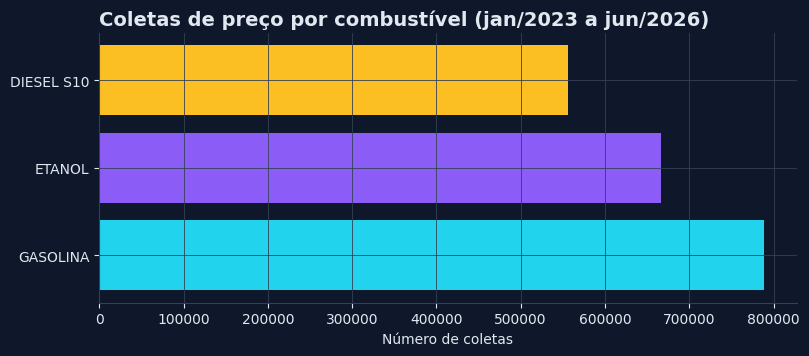

In [35]:
contagem = df["produto"].value_counts()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.barh(contagem.index, contagem.values, color=[CORES[p] for p in contagem.index])
ax.set_title("Coletas de preço por combustível (jan/2023 a jun/2026)")
ax.set_xlabel("Número de coletas")
plt.show()

### Preparando o SQL (SQLite)
O SQLite já vem com o Python: não precisa instalar nada. O banco é criado na memória e recebe uma tabela `precos` com as colunas usadas nas perguntas.

In [36]:
conn = sqlite3.connect(":memory:")

colunas_sql = ["estado", "municipio", "cnpj", "produto", "valor_venda",
               "bandeira_grupo", "ano", "mes", "ano_mes", "semana"]
df_sql = df[colunas_sql].copy()
df_sql["semana"] = df_sql["semana"].dt.strftime("%Y-%m-%d")

df_sql.to_sql("precos", conn, index=False)
print("Tabela 'precos' criada no SQLite")

Tabela 'precos' criada no SQLite


In [37]:
consulta = """
SELECT produto,
       COUNT(*)                 AS coletas,
       ROUND(AVG(valor_venda), 2) AS preco_medio
FROM precos
GROUP BY produto
ORDER BY preco_medio DESC
"""

pd.read_sql(consulta, conn)

,produto,coletas,preco_medio
0,DIESEL S10,556250,6.14
1,GASOLINA,788126,5.99
2,ETANOL,666357,4.24


### P1. Como evoluíram os preços de gasolina, etanol e diesel no Brasil, em SP e em Rio Preto?

In [38]:
def preco_mensal(dados):
    return dados.groupby(["ano_mes", "produto"])["valor_venda"].mean().unstack()

recortes = {
    "Brasil": preco_mensal(df),
    "Estado de SP": preco_mensal(df[df["estado"] == "SP"]),
    "São José do Rio Preto": preco_mensal(df[df["municipio"] == "SAO JOSE DO RIO PRETO"]),
}

recortes["São José do Rio Preto"].head()

produto,DIESEL S10,ETANOL,GASOLINA
ano_mes,,,
2023-01,6.279286,3.489070,4.832558
2023-02,5.902444,3.403889,4.827361
2023-03,5.659149,3.491831,5.228592
2023-04,5.501818,3.672090,5.270000
2023-05,5.231356,3.858765,5.403951


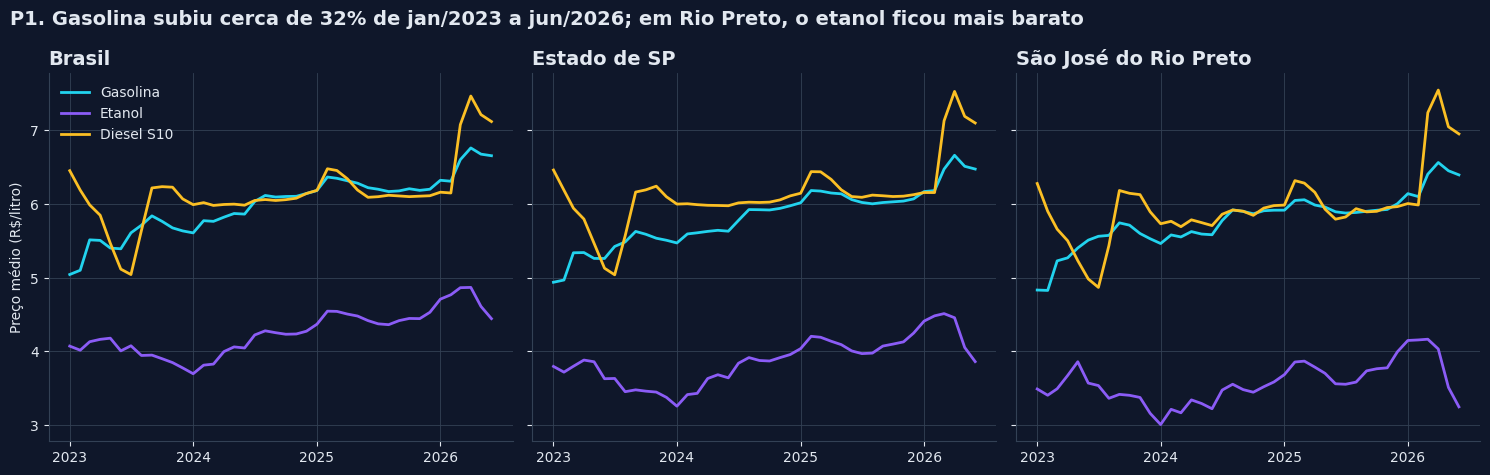

In [39]:
fig, eixos = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)

for ax, (nome, tabela) in zip(eixos, recortes.items()):
    for produto in ["GASOLINA", "ETANOL", "DIESEL S10"]:
        ax.plot(pd.to_datetime(tabela.index), tabela[produto],
                color=CORES[produto], label=produto.title())
    ax.set_title(nome)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

eixos[0].set_ylabel("Preço médio (R$/litro)")
eixos[0].legend(loc="upper left")
fig.suptitle("P1. Gasolina subiu cerca de 32% de jan/2023 a jun/2026; em Rio Preto, o etanol ficou mais barato",
             x=0.01, ha="left", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [40]:
for nome, tabela in recortes.items():
    print(nome)
    print(tabela.iloc[[0, -1]].round(2))
    print()

Brasil
produto  DIESEL S10  ETANOL  GASOLINA
ano_mes                              
2023-01        6.45    4.07      5.04
2026-06        7.12    4.44      6.66

Estado de SP
produto  DIESEL S10  ETANOL  GASOLINA
ano_mes                              
2023-01        6.46    3.80      4.94
2026-06        7.10    3.86      6.48

São José do Rio Preto
produto  DIESEL S10  ETANOL  GASOLINA
ano_mes                              
2023-01        6.28    3.49      4.83
2026-06        6.95    3.25      6.40



#### Conclusão
- A gasolina foi o combustível que mais subiu: de 31% a 33% entre jan/2023 e jun/2026 nos três recortes. No Brasil, passou de R\$ 5,04 para R\$ 6,66.
- O diesel S10 subiu cerca de 10%, mas oscilou bastante: caiu no 1º semestre de 2023 e deu um salto no começo de 2026.
- O etanol quase não mudou em SP (+2%) e ficou mais barato em Rio Preto (queda de 7%, de R\$ 3,49 para R\$ 3,25). Em jun/2026, o etanol de Rio Preto estava 16% abaixo da média do estado. A queda a partir de abril coincide com o início da safra da cana, o que testo na P3.

### P2. Quais estados têm a gasolina e o etanol mais caros e mais baratos? Qual a diferença?
Recorte: 1º semestre de 2026, o período mais recente da base.

In [41]:
consulta_ranking = """
SELECT estado,
       produto,
       ROUND(AVG(valor_venda), 2) AS preco_medio
FROM precos
WHERE ano = 2026
  AND produto IN ('GASOLINA', 'ETANOL')
GROUP BY estado, produto
ORDER BY produto, preco_medio DESC
"""

ranking = pd.read_sql(consulta_ranking, conn)
ranking.head(10)

,estado,produto,preco_medio
0,AP,ETANOL,5.90
1,RN,ETANOL,5.59
2,RO,ETANOL,5.57
3,AC,ETANOL,5.46
4,RR,ETANOL,5.42
5,AM,ETANOL,5.35
6,TO,ETANOL,5.31
7,CE,ETANOL,5.29
8,MA,ETANOL,5.28
9,SE,ETANOL,5.26


In [42]:
consulta_diferenca = """
WITH media_estado AS (
    SELECT estado, produto, AVG(valor_venda) AS preco_medio
    FROM precos
    WHERE ano = 2026
      AND produto IN ('GASOLINA', 'ETANOL')
    GROUP BY estado, produto
)
SELECT produto,
       ROUND(MIN(preco_medio), 2)                         AS menor_preco,
       ROUND(MAX(preco_medio), 2)                         AS maior_preco,
       ROUND(MAX(preco_medio) - MIN(preco_medio), 2)      AS diferenca_reais,
       ROUND((MAX(preco_medio) / MIN(preco_medio) - 1) * 100, 1) AS diferenca_pct
FROM media_estado
GROUP BY produto
"""

pd.read_sql(consulta_diferenca, conn)

,produto,menor_preco,maior_preco,diferenca_reais,diferenca_pct
0,ETANOL,4.29,5.90,1.61,37.4
1,GASOLINA,6.34,7.48,1.14,18.0


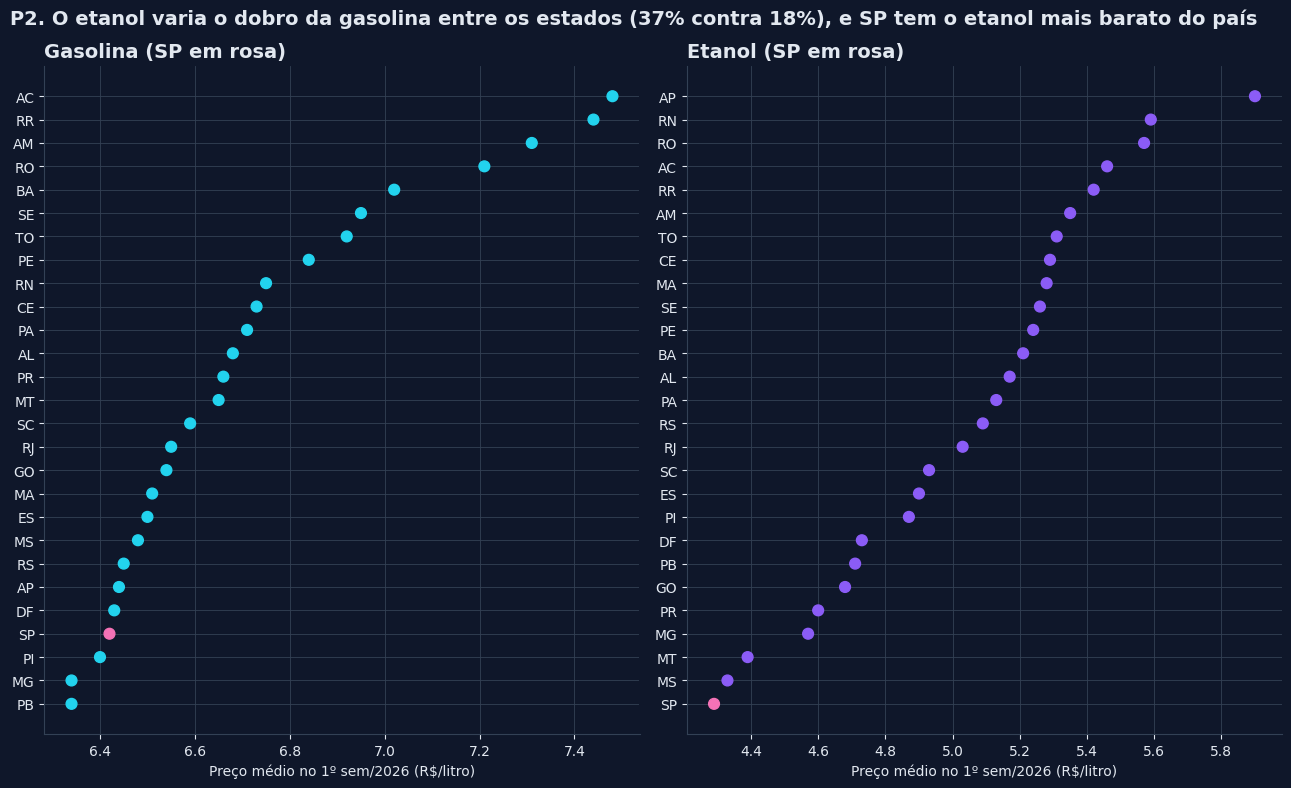

In [43]:
tabela_p2 = ranking.pivot(index="estado", columns="produto", values="preco_medio")

fig, eixos = plt.subplots(1, 2, figsize=(13, 8))

for ax, produto in zip(eixos, ["GASOLINA", "ETANOL"]):
    dados = tabela_p2[produto].sort_values()
    cores = [CORES["destaque"] if uf == "SP" else CORES[produto] for uf in dados.index]
    ax.scatter(dados.values, dados.index, color=cores, s=60, zorder=3)
    ax.set_title(f"{produto.title()} (SP em rosa)")
    ax.set_xlabel("Preço médio no 1º sem/2026 (R$/litro)")

fig.suptitle("P2. O etanol varia o dobro da gasolina entre os estados (37% contra 18%), e SP tem o etanol mais barato do país",
             x=0.01, ha="left", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#### Conclusão
- No 1º semestre de 2026, a gasolina custou de R\$ 6,34 (PB) a R\$ 7,48 (AC), uma diferença de 18% entre o estado mais barato e o mais caro.
- No etanol a diferença é o dobro: de R\$ 4,29 em SP a R\$ 5,90 no AP (+37%). Os 6 estados com etanol mais barato (SP, MS, MT, MG, PR e GO) produzem cana. Os mais caros ficam no Norte e no Nordeste, longe das usinas.
- SP tem o etanol mais barato do país e a 4ª gasolina mais barata, o que favorece quem abastece com etanol na região de Rio Preto.

### P3. Quando compensa abastecer com etanol? (regra dos 70%)
O etanol rende cerca de 30% menos que a gasolina, então ele compensa quando custa até 70% do preço dela. Calculei essa razão por estado e por mês, com Rio Preto como um "local" à parte para comparar.

In [44]:
consulta_p3 = """
WITH base AS (
    SELECT estado AS local, ano_mes, produto, valor_venda
    FROM precos
    UNION ALL
    SELECT 'Rio Preto' AS local, ano_mes, produto, valor_venda
    FROM precos
    WHERE municipio = 'SAO JOSE DO RIO PRETO'
),
mensal AS (
    SELECT local,
           ano_mes,
           AVG(CASE WHEN produto = 'ETANOL'   THEN valor_venda END) AS etanol,
           AVG(CASE WHEN produto = 'GASOLINA' THEN valor_venda END) AS gasolina
    FROM base
    WHERE produto IN ('ETANOL', 'GASOLINA')
    GROUP BY local, ano_mes
)
SELECT local,
       ano_mes,
       ROUND(etanol / gasolina, 3) AS razao,
       CASE WHEN etanol / gasolina <= 0.70 THEN 1 ELSE 0 END AS compensa
FROM mensal
ORDER BY local, ano_mes
"""

p3 = pd.read_sql(consulta_p3, conn)
p3[p3["local"] == "Rio Preto"].head(12)

,local,ano_mes,razao,compensa
966,Rio Preto,2023-01,0.722,0
967,Rio Preto,2023-02,0.705,0
968,Rio Preto,2023-03,0.668,1
969,Rio Preto,2023-04,0.697,1
970,Rio Preto,2023-05,0.714,0
971,Rio Preto,2023-06,0.648,1
972,Rio Preto,2023-07,0.636,1
973,Rio Preto,2023-08,0.603,1
974,Rio Preto,2023-09,0.595,1
975,Rio Preto,2023-10,0.596,1


In [45]:
resumo_p3 = (p3.groupby("local")["compensa"].mean() * 100).round(0).sort_values(ascending=False)

print("Rio Preto:", resumo_p3["Rio Preto"], "% dos meses")
resumo_p3.head(10)

Rio Preto: 93.0 % dos meses


,compensa
local,
Rio Preto,93.0
MT,93.0
MS,86.0
SP,83.0
PR,69.0
GO,57.0
MG,55.0
DF,50.0
AM,36.0


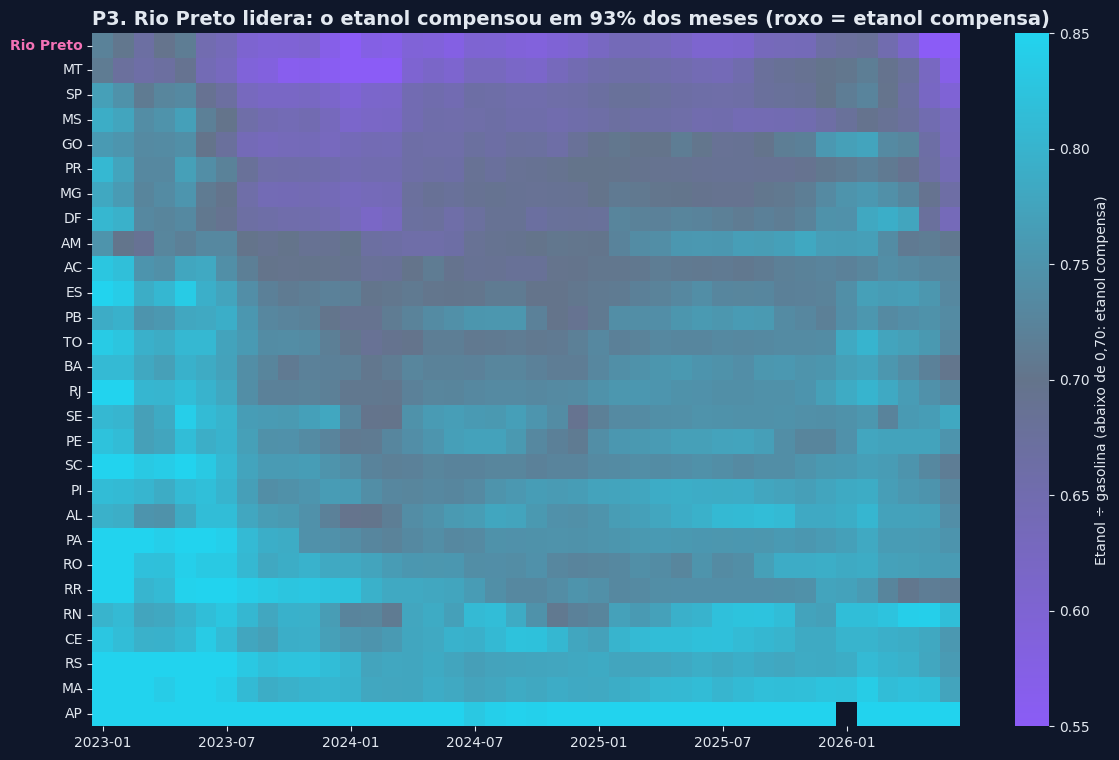

In [46]:
mapa = p3.pivot(index="local", columns="ano_mes", values="razao")
mapa = mapa.loc[mapa.mean(axis=1).sort_values().index]

cores_p3 = LinearSegmentedColormap.from_list(
    "etanol_gasolina", [CORES["ETANOL"], "#64748B", CORES["GASOLINA"]]
)

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(mapa, cmap=cores_p3, center=0.70, vmin=0.55, vmax=0.85, ax=ax, xticklabels=6,
            cbar_kws={"label": "Etanol ÷ gasolina (abaixo de 0,70: etanol compensa)"})
ax.grid(False)

for rotulo in ax.get_yticklabels():
    if rotulo.get_text() == "Rio Preto":
        rotulo.set_color(CORES["destaque"])
        rotulo.set_fontweight("bold")

ax.set_title("P3. Rio Preto lidera: o etanol compensou em 93% dos meses (roxo = etanol compensa)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.show()

In [47]:
p3["mes"] = p3["ano_mes"].str[-2:]

sazonal = p3[p3["local"].isin(["Rio Preto", "SP"])].pivot_table(
    index="mes", columns="local", values="razao", aggfunc="mean"
).round(3)

sazonal

local,Rio Preto,SP
mes,,
01,0.643,0.688
02,0.650,0.691
03,0.632,0.674
04,0.634,0.678
05,0.617,0.668
06,0.584,0.648
07,0.614,0.664
08,0.604,0.651
09,0.606,0.649


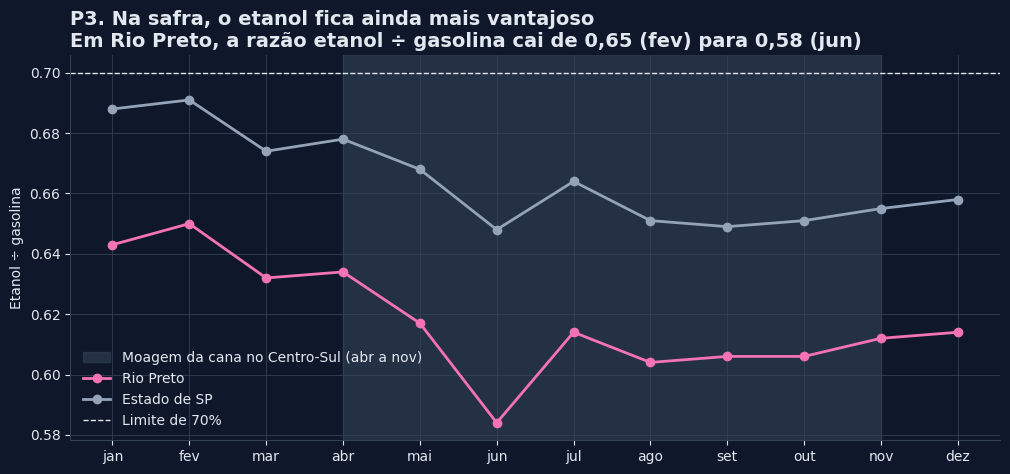

In [48]:
meses = ["jan", "fev", "mar", "abr", "mai", "jun", "jul", "ago", "set", "out", "nov", "dez"]
x = sazonal.index.astype(int)

fig, ax = plt.subplots(figsize=(12, 5))
ax.axvspan(4, 11, color=GRADE, alpha=0.6, label="Moagem da cana no Centro-Sul (abr a nov)")
ax.plot(x, sazonal["Rio Preto"], color=CORES["destaque"], marker="o", label="Rio Preto")
ax.plot(x, sazonal["SP"], color="#94A3B8", marker="o", label="Estado de SP")
ax.axhline(0.70, color=TEXTO, linestyle="--", linewidth=1, label="Limite de 70%")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses)
ax.set_ylabel("Etanol ÷ gasolina")
ax.set_title("P3. Na safra, o etanol fica ainda mais vantajoso\n"
             "Em Rio Preto, a razão etanol ÷ gasolina cai de 0,65 (fev) para 0,58 (jun)")
ax.legend(loc="lower left", fontsize=10)
plt.show()

#### Conclusão
- Em Rio Preto, o etanol ficou abaixo de 70% do preço da gasolina em 39 dos 42 meses (93%). É o maior índice da base, empatado com MT, e bem acima do estado de SP como um todo (83%). Os 7 primeiros do ranking são estados produtores de cana.
- Existe um padrão de safra. Em Rio Preto, a razão etanol/gasolina sobe em janeiro e fevereiro (0,64 a 0,65) e cai de junho a dezembro (0,58 a 0,61). Na safra, o etanol custa cerca de 60% do preço da gasolina.
- Mesmo em fevereiro, o pior mês, a média de Rio Preto ficou abaixo de 0,70. Para quem abastece na cidade, o etanol foi a melhor escolha em quase todo o período.
- Limitações: cada mês do ano aparece só 3 ou 4 vezes na base, então o padrão de safra é uma tendência, não uma regra. O Amapá tem um mês sem coleta.

### P4. Postos com bandeira cobram mais que os de bandeira branca? Quanto?
Para a comparação ser justa, cada bandeira é comparada com a bandeira branca da mesma cidade, na mesma semana.

In [49]:
consulta_p4 = """
WITH media_grupo AS (
    SELECT estado, municipio, semana, produto, bandeira_grupo,
           AVG(valor_venda) AS preco
    FROM precos
    GROUP BY estado, municipio, semana, produto, bandeira_grupo
),
branca AS (
    SELECT estado, municipio, semana, produto, preco AS preco_branca
    FROM media_grupo
    WHERE bandeira_grupo = 'Branca'
)
SELECT g.bandeira_grupo,
       g.produto,
       COUNT(*)                                     AS comparacoes,
       ROUND(AVG(g.preco - b.preco_branca) * 100, 1) AS diferenca_centavos
FROM media_grupo AS g
JOIN branca AS b
  ON  g.estado    = b.estado
  AND g.municipio = b.municipio
  AND g.semana    = b.semana
  AND g.produto   = b.produto
WHERE g.bandeira_grupo <> 'Branca'
GROUP BY g.bandeira_grupo, g.produto
ORDER BY g.produto, diferenca_centavos DESC
"""

p4 = pd.read_sql(consulta_p4, conn)
p4

,bandeira_grupo,produto,comparacoes,diferenca_centavos
0,Petrobras (Vibra),DIESEL S10,41779,16.9
1,Ipiranga,DIESEL S10,43736,16.6
2,Shell (Raízen),DIESEL S10,32652,12.7
3,Outras,DIESEL S10,25996,5.2
4,Petrobras (Vibra),ETANOL,44391,16.6
5,Ipiranga,ETANOL,42945,15.5
6,Shell (Raízen),ETANOL,39819,14.4
7,Outras,ETANOL,25684,7.1
8,Petrobras (Vibra),GASOLINA,51843,15.5
9,Ipiranga,GASOLINA,49808,14.9


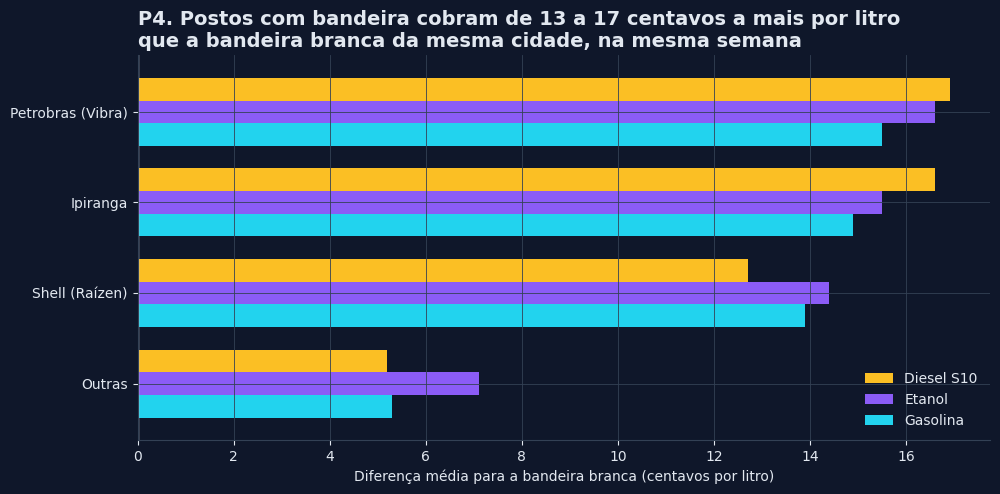

In [50]:
tabela_p4 = p4.pivot(index="bandeira_grupo", columns="produto", values="diferenca_centavos")
tabela_p4 = tabela_p4.loc[tabela_p4["GASOLINA"].sort_values().index]
dados_p4 = tabela_p4[["GASOLINA", "ETANOL", "DIESEL S10"]].rename(columns=str.title)

fig, ax = plt.subplots(figsize=(11, 5))
dados_p4.plot(kind="barh", ax=ax, width=0.75,
              color=[CORES["GASOLINA"], CORES["ETANOL"], CORES["DIESEL S10"]])
ax.axvline(0, color=TEXTO, linewidth=1)
ax.set_xlabel("Diferença média para a bandeira branca (centavos por litro)")
ax.set_ylabel("")
ax.legend(loc="lower right", reverse=True)
ax.set_title("P4. Postos com bandeira cobram de 13 a 17 centavos a mais por litro\n"
             "que a bandeira branca da mesma cidade, na mesma semana")
plt.show()

#### Conclusão
- Na mesma cidade e na mesma semana, os postos das 3 grandes bandeiras cobram de 13 a 17 centavos a mais por litro que os de bandeira branca, nos três combustíveis. Cada diferença foi calculada com mais de 30 mil comparações.
- Petrobras (Vibra) é a mais cara nos três combustíveis (15,5 a 16,9 centavos a mais). Shell (Raízen) é a mais barata entre as grandes na gasolina (13,9) e no diesel (12,7).
- As bandeiras regionais ("Outras") ficam bem mais perto da branca: 5 a 7 centavos a mais.
- Em reais: 50 litros de gasolina num posto Petrobras custam em média R\$ 7,75 a mais do que num bandeira branca da mesma cidade. Com um tanque por semana, dá cerca de R\$ 400 por ano.
- Limitação: a base só tem o preço. Serviço, aditivos e programas de fidelidade não entram na comparação.

### P5. Em Rio Preto, quanto o motorista economiza escolhendo o posto certo?
Para cada semana, comparo o preço dos 10% postos mais baratos da cidade com o dos 10% mais caros (percentis 10 e 90). Usei percentis em vez do menor e do maior preço para que um único valor fora do comum não distorça a conta.

Para converter em reais, considerei 1 tanque de 50 litros por semana (52 por ano).

In [51]:
rp = df[df["municipio"] == "SAO JOSE DO RIO PRETO"]

# Quantos postos a ANP pesquisou por semana em Rio Preto, para cada combustível
postos_semana = rp.groupby(["semana", "produto"])["cnpj"].nunique()
postos_semana.groupby("produto").describe().round(1)

,count,mean,std,min,25%,50%,75%,max
produto,,,,,,,,
DIESEL S10,183.0,10.3,1.5,4.0,9.0,10.0,11.0,15.0
ETANOL,183.0,18.2,1.6,5.0,18.0,19.0,19.0,19.0
GASOLINA,183.0,18.1,1.6,5.0,18.0,19.0,19.0,19.0


In [52]:
# Em cada semana: preço que separa os 10% postos mais baratos (p10) e os 10% mais caros (p90)
faixa = rp.groupby(["semana", "produto"])["valor_venda"].quantile([0.10, 0.90]).unstack()
faixa.columns = ["p10", "p90"]
faixa["diferenca"] = faixa["p90"] - faixa["p10"]

# Média das semanas, convertida em reais por tanque e por ano
economia = faixa.groupby("produto")["diferenca"].mean().to_frame("diferenca_por_litro")
economia["por_tanque_50L"] = economia["diferenca_por_litro"] * 50
economia["por_ano_52_tanques"] = economia["por_tanque_50L"] * 52

precos_medios = faixa.groupby("produto")[["p10", "p90"]].mean()
economia = economia.join(precos_medios)
economia["diferenca_pct"] = (economia["p90"] / economia["p10"] - 1) * 100
economia.round(2)

,diferenca_por_litro,por_tanque_50L,por_ano_52_tanques,p10,p90,diferenca_pct
produto,,,,,,
DIESEL S10,0.42,21.22,1103.48,5.77,6.20,7.35
ETANOL,0.34,17.12,890.37,3.42,3.76,10.01
GASOLINA,0.59,29.36,1526.68,5.44,6.03,10.79


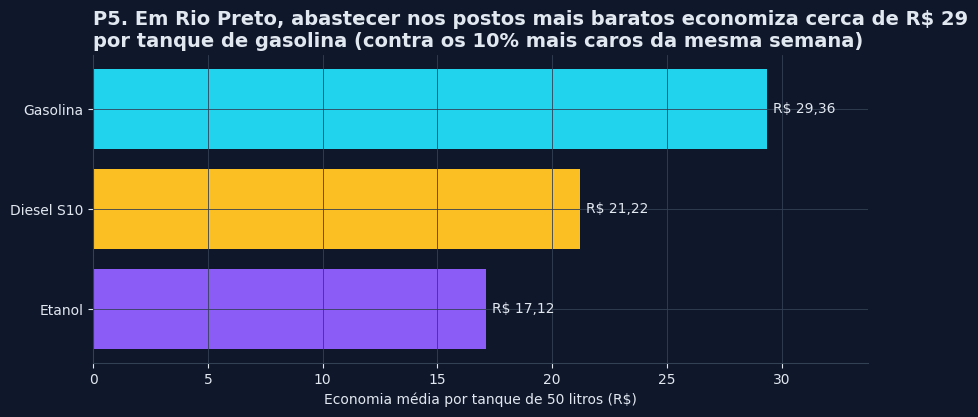

In [53]:
economia_ord = economia.sort_values("por_tanque_50L")
rotulos = [f"R$ {v:.2f}".replace(".", ",") for v in economia_ord["por_tanque_50L"]]

fig, ax = plt.subplots(figsize=(10, 4))
barras = ax.barh([p.title() for p in economia_ord.index], economia_ord["por_tanque_50L"],
                 color=[CORES[p] for p in economia_ord.index])
ax.bar_label(barras, labels=rotulos, padding=4, color=TEXTO)
ax.set_xlim(0, economia_ord["por_tanque_50L"].max() * 1.15)
ax.set_xlabel("Economia média por tanque de 50 litros (R$)")
ax.set_title("P5. Em Rio Preto, abastecer nos postos mais baratos economiza cerca de R$ 29\n"
             "por tanque de gasolina (contra os 10% mais caros da mesma semana)")
plt.show()

#### Conclusão
- A ANP pesquisou em média 19 postos por semana em Rio Preto para gasolina e etanol, e 10 para diesel S10, ao longo de 183 semanas.
- Abastecer entre os postos mais baratos, em vez dos mais caros, economiza em média 59 centavos por litro de gasolina (R\$ 5,44 contra R\$ 6,03). No diesel S10 são 42 centavos e no etanol, 34.
- Num tanque de 50 litros, isso dá R\$ 29 na gasolina, R\$ 21 no diesel e R\$ 17 no etanol. Com um tanque por semana, a economia passa de R\$ 1.500 por ano na gasolina. Quem enche o tanque a cada 15 dias economiza metade disso.
- A diferença entre postos da mesma cidade (59 centavos) é quase 4 vezes a diferença média entre bandeiras (13 a 17 centavos, P4). Pesquisar o posto pesa mais no bolso do que escolher a bandeira.

### P6. Rio Preto é cara ou barata em relação às cidades vizinhas e à média de SP?
Fernandópolis não está na pesquisa da ANP, então comparei as cidades do noroeste paulista que estão na base. Recorte: 1º semestre de 2026, o mesmo da P2.

In [54]:
# Cidades do noroeste paulista (regiões de Rio Preto, Araçatuba e Barretos) que podem estar na pesquisa
candidatas = [
    "SAO JOSE DO RIO PRETO", "MIRASSOL", "CATANDUVA", "VOTUPORANGA", "JALES", "SANTA FE DO SUL",
    "FERNANDOPOLIS", "ARACATUBA", "BIRIGUI", "PENAPOLIS", "ANDRADINA", "LINS", "BARRETOS",
    "BEBEDOURO", "OLIMPIA", "NOVO HORIZONTE", "JOSE BONIFACIO", "TANABI", "PEREIRA BARRETO",
    "ILHA SOLTEIRA", "MONTE APRAZIVEL", "NOVA GRANADA", "GUARACI", "COLINA", "ITAJOBI",
]

sp = df[df["estado"] == "SP"]
regiao = sp[sp["municipio"].isin(candidatas)]

print("Cidades da região encontradas na base:", regiao["municipio"].nunique())
regiao.groupby("municipio")["semana"].nunique().sort_values(ascending=False)

Cidades da região encontradas na base: 12


,semana
municipio,
ARACATUBA,183
SAO JOSE DO RIO PRETO,183
VOTUPORANGA,182
BARRETOS,181
BIRIGUI,179
LINS,178
CATANDUVA,177
JALES,172
BEBEDOURO,170


In [55]:
# Preço médio no 1º semestre de 2026 (mesmo recorte da P2), por cidade e combustível
precos_cidades = (regiao[regiao["ano"] == 2026]
                  .groupby(["municipio", "produto"])["valor_venda"].mean()
                  .unstack())
media_sp = sp[sp["ano"] == 2026].groupby("produto")["valor_venda"].mean()

print("Média do estado de SP no 1º sem/2026:")
print(media_sp.round(2))

precos_cidades["posicao_gasolina"] = precos_cidades["GASOLINA"].rank().astype(int)
precos_cidades["posicao_etanol"] = precos_cidades["ETANOL"].rank().astype(int)
precos_cidades.round(2).sort_values("GASOLINA")

Média do estado de SP no 1º sem/2026:
produto
DIESEL S10    6.91
ETANOL        4.29
GASOLINA      6.42
Name: valor_venda, dtype: float64


produto,DIESEL S10,ETANOL,GASOLINA,posicao_gasolina,posicao_etanol
municipio,,,,,
LINS,6.67,3.81,6.20,1,1
ARACATUBA,6.81,3.94,6.29,2,3
SAO JOSE DO RIO PRETO,6.81,3.86,6.35,3,2
CATANDUVA,6.81,4.19,6.37,4,9
JOSE BONIFACIO,6.67,3.98,6.39,5,4
BEBEDOURO,6.77,4.21,6.40,6,10
BARRETOS,6.82,4.17,6.48,7,7
JALES,6.84,4.18,6.49,8,8
BIRIGUI,6.83,4.07,6.53,9,6


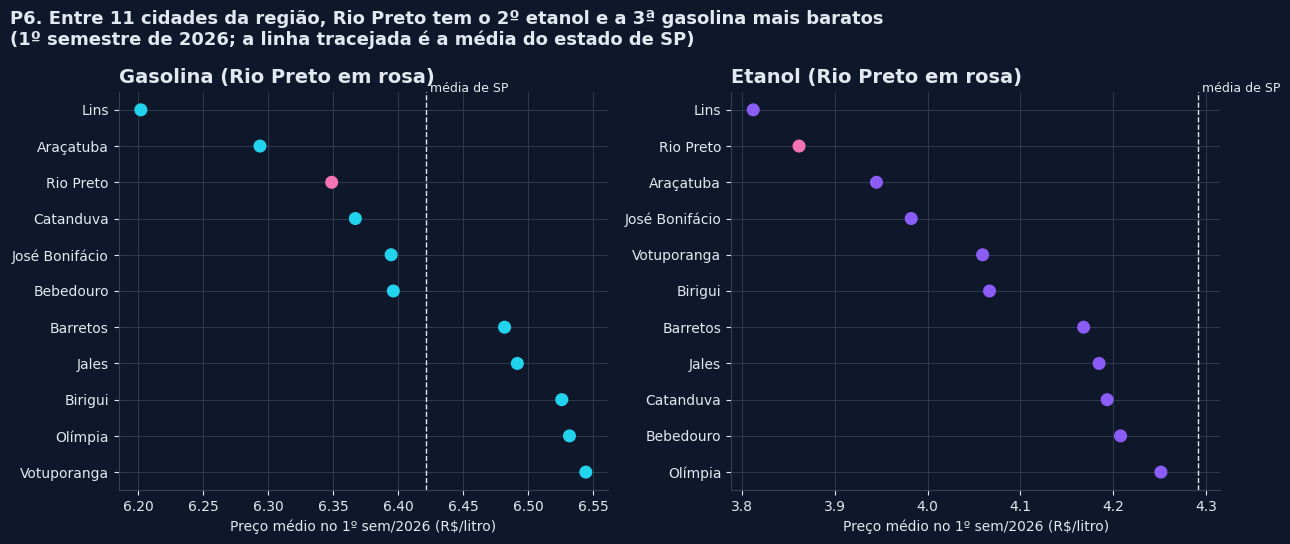

In [56]:
NOMES = {
    "SAO JOSE DO RIO PRETO": "Rio Preto", "ARACATUBA": "Araçatuba", "VOTUPORANGA": "Votuporanga",
    "BARRETOS": "Barretos", "BIRIGUI": "Birigui", "LINS": "Lins", "CATANDUVA": "Catanduva",
    "JALES": "Jales", "BEBEDOURO": "Bebedouro", "JOSE BONIFACIO": "José Bonifácio",
    "OLIMPIA": "Olímpia", "MIRASSOL": "Mirassol",
}

fig, eixos = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, produto in zip(eixos, ["GASOLINA", "ETANOL"]):
    dados = precos_cidades[produto].sort_values(ascending=False)
    nomes = [NOMES[m] for m in dados.index]
    cores = [CORES["destaque"] if m == "SAO JOSE DO RIO PRETO" else CORES[produto] for m in dados.index]
    ax.scatter(dados.values, nomes, color=cores, s=70, zorder=3)
    ax.axvline(media_sp[produto], color=TEXTO, linestyle="--", linewidth=1)
    ax.text(media_sp[produto], len(dados) - 0.6, " média de SP", fontsize=9, va="bottom")
    ax.set_title(f"{produto.title()} (Rio Preto em rosa)")
    ax.set_xlabel("Preço médio no 1º sem/2026 (R$/litro)")

fig.suptitle("P6. Entre 11 cidades da região, Rio Preto tem o 2º etanol e a 3ª gasolina mais baratos\n"
             "(1º semestre de 2026; a linha tracejada é a média do estado de SP)",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### Conclusão
- Entre as 11 cidades da região com dados no 1º semestre de 2026 (Mirassol não teve coleta no período), Rio Preto tem o 2º etanol mais barato (R\$ 3,86) e a 3ª gasolina mais barata (R\$ 6,35). Lins é a mais barata nos dois.
- O etanol de Rio Preto está 10% abaixo da média do estado (R\$ 4,29). Na gasolina a vantagem é pequena: 7 centavos abaixo da média de SP (R\$ 6,42).
- Todas as cidades da região têm etanol abaixo da média estadual. É o efeito de estar perto das usinas, o mesmo padrão da P2 e da P3.
- Jales e Votuporanga, as cidades da base mais próximas de Fernandópolis, estão entre as gasolinas mais caras da região (R\$ 6,49 e R\$ 6,54), acima da média de SP.

## 5. Conclusões e recomendações

### O que encontrei
1. A gasolina foi o combustível que mais subiu: cerca de 32% de jan/2023 a jun/2026 (no Brasil, de R\$ 5,04 para R\$ 6,66). O diesel S10 subiu cerca de 10% e o etanol, 9%.
2. Entre os estados, o preço do etanol varia o dobro do da gasolina (37% contra 18%). SP tem o etanol mais barato do país (R\$ 4,29 no 1º semestre de 2026).
3. Em Rio Preto, o etanol compensou em 93% dos meses, o maior índice da base. O melhor momento é a safra (razão de 0,58 em junho).
4. Os postos das 3 grandes bandeiras cobram de 13 a 17 centavos a mais por litro que a bandeira branca da mesma cidade e semana.
5. Em Rio Preto, a diferença entre os postos mais baratos e os mais caros é de 59 centavos por litro de gasolina, cerca de R\$ 29 por tanque. Pesa mais que a bandeira.
6. Rio Preto é barata para a região: tem o 2º etanol e a 3ª gasolina mais baratos entre 11 cidades, com o etanol 10% abaixo da média do estado.

### Para o consumidor (Rio Preto e região)
1. Prefira o etanol. Na cidade, ele compensou em 39 de 42 meses. Vale conferir a conta dos 70% em janeiro e fevereiro, quando a vantagem diminui.
2. Pesquise o posto antes de pensar na bandeira. Os postos mais baratos da cidade economizam cerca de R\$ 29 por tanque de gasolina, e a bandeira explica só 13 a 17 centavos por litro dessa diferença.
3. De junho a dezembro, o etanol fica em torno de 60% do preço da gasolina. É o melhor período do ano para usá-lo.

### Para o dono de posto
1. Bandeira branca tem espaço para competir por preço. Os bandeirados cobram de 13 a 17 centavos a mais na mesma cidade e semana, e essa diferença é o principal argumento de um posto independente.
2. Na região, deixe a vantagem do etanol visível. Como ele compensa quase o ano todo, manter o etanol abaixo de 70% da própria gasolina, e mostrar isso na placa, conversa com a conta que o motorista já faz.
3. Acompanhe os concorrentes toda semana. A diferença entre postos da mesma cidade chega a 59 centavos na gasolina, então quem pesquisa encontra alternativa fácil. Os dados abertos da ANP permitem fazer esse acompanhamento sem custo.

### Limitações
- A ANP pesquisa uma amostra de postos, não todos. Cidades menores, como Fernandópolis, ficam de fora.
- A coluna Valor de Compra veio vazia em todos os semestres, então não dá para analisar margem.
- São 3,5 anos de dados. Os padrões por mês (como o da safra) são tendências, não regras.